<a href="https://colab.research.google.com/github/Pabsgc/Breast-Cancer-ML/blob/Prototypes/RF_version_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest para cáncer de mama

Programación de un modelo RF clasificatorio para cáncer de mama. El set contiene:

- **Número de clases:** 2
- **Datos por clase:** 212(M),357(B)
- **Total:** 569
- **Dimensionalidad:** 30
- **Tipo de datos:** Nº Reales y Positivos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Obtención dataset
from sklearn.datasets import load_breast_cancer
dataset = load_breast_cancer()
print(dataset.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [2]:
# Separación datos / etiquetas
X, y = dataset["data"], dataset["target"]
print(X.shape)
print(y.shape)
print(type(X))

(569, 30)
(569,)
<class 'numpy.ndarray'>


In [3]:
# Comprobación de datos, primer paciente
print(X[0])
print(y[0])

[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]
0


# Split

In [4]:
# Aleatorización y seccionamiento del dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
# Se reserva un 10% para validación final, con semilla
print(X_train.shape)
print(X_test.shape)

(512, 30)
(57, 30)


# Random Search (f1)

In [5]:
# Creación del modelo Random Forest con hiperparámetros fijos
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', verbose=0, random_state=42)

In [ ]:
# Búsqueda aleatoria de hiperparámetros óptimos

param_dist = {
    'n_estimators': [50, 100, 200, 500], # Nº de árboles

    # Reducción de Overfitting
    'max_depth': [3, 5, 10, 20, None], # Profundiades de cada árbol. 'max_leaf_nodes' lo ensucia
    'min_samples_split': [2, 5, 10], # Mínimo de datos para división de nodo
    'min_samples_leaf': [2, 5, 10, 20], # Mínimo de datos al fin de hoja, no debe ser 1 (1 persona sóla es ruido en medicina) ni 50 (10% de datos, demasiado suave, pierde capacidad de predicción)
    'ccp_alpha': [0.0, 0.001, 0.01, 0.02, 0.05], # Cost Complexity Pruning - poda de árbol complejo

    # Calidad de división
    'criterion': ['gini', 'entropy'], # Mide calidad de división según pureza o desorden
    'max_features': [None, 'sqrt', 'log2', 0.5], # Cantidad de características aleatorias por árbol. Diversifica bosque
    'min_impurity_decrease': [0.0, 0.01, 0.03, 0.05], # Mínima reducción de impureza para división de nodo
}

from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(rf, param_dist, n_iter=200, cv=5, random_state=42, scoring='f1') # Semilla controla combinaciones elegidas. scoring=[f1,recall,precission,accuracy]
random_search.fit(X_train, y_train)

rs_model = random_search.best_estimator_ # Guarda mejor modelo
print(f"Mejor F1: {random_search.best_score_}") # Imprime mejor métrica

0.9702473237356959


In [ ]:
# Impresión de mejor combinación de hiperparámetros
print(f"Mejores parámetros: {random_search.best_params_}")

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 5, 'min_impurity_decrease': 0.0, 'max_features': None, 'max_depth': 20, 'criterion': 'entropy', 'ccp_alpha': 0.01}


#Downloading Results (RS)

In [ ]:
# Descarga de modelo y dataframe de resultados

import joblib
joblib.dump(rs_model, 'rs_model.pkl')
print("Modelo guardado con éxito.")

import pandas as pd
rs_df = pd.DataFrame(random_search.cv_results_)

from google.colab import files
rs_df.to_csv('resultados_random_search.csv', index=False)
print("Dataframe guardado con éxito.")

Modelo guardado con éxito.


#Loading Results (RS)

In [6]:

import pandas as pd
import joblib

rs_df = pd.read_csv('resultados_random_search.csv')
rs_model = joblib.load('rs_model.pkl')

#Data Graphing

---



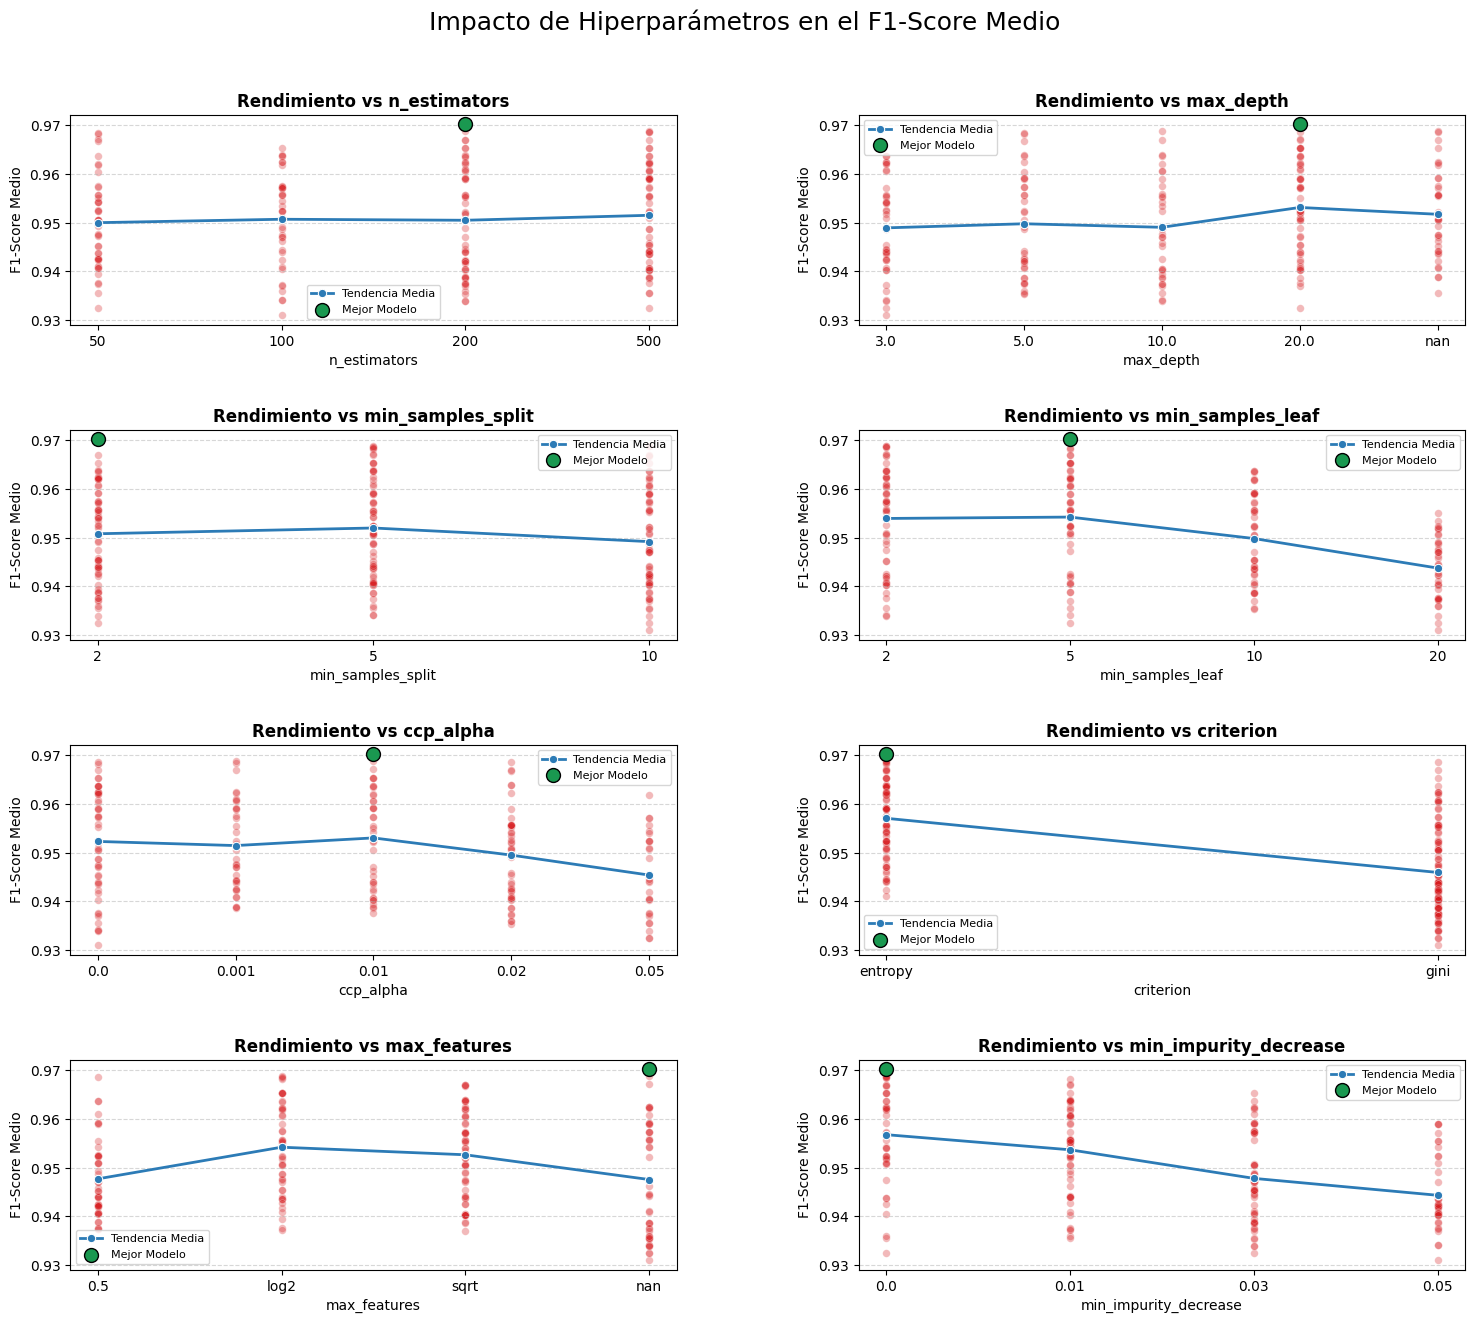

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Asegurarnos de tener el ganador (Rank 1)
ganador = rs_df[rs_df['rank_test_score'] == 1].iloc[0]

parametros = ['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf',
              'param_ccp_alpha', 'param_criterion', 'param_max_features', 'param_min_impurity_decrease']

plt.figure(figsize=(18, 15))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.suptitle("Impacto de Hiperparámetros en el F1-Score Medio", fontsize=18, y=0.95)

for i, param in enumerate(parametros):
    plt.subplot(4, 2, i + 1)

    # TRUCO: Ordenamos el DF por el valor real (numérico) antes de convertir a string
    # Así el eje X mantendrá el orden 3, 5, 10, 20...
    df_plot = rs_df.sort_values(by=param).copy()

    # Ahora convertimos a string para que Matplotlib no se queje con los 'nan'
    df_plot[param] = df_plot[param].astype(str)

    # A. Dibujar la tendencia media (Línea azul)
    # marker='o' ayuda a ver dónde están los puntos reales en la línea
    sns.lineplot(data=df_plot, x=param, y='mean_test_score', errorbar=None, color='#2c7bb6', linewidth=2, marker='o', label='Tendencia Media')

    # B. Dibujar todas las combinaciones (Puntos rojos pequeños)
    sns.scatterplot(data=df_plot, x=param, y='mean_test_score', alpha=0.3, color='#d7191c', s=30)

    # C. Destacar el ganador (Punto verde grande)
    valor_ganador = str(ganador[param])
    score_ganador = ganador['mean_test_score']

    plt.scatter(valor_ganador, score_ganador, color='#1a9850', s=100, edgecolors='black', zorder=5, label='Mejor Modelo')

    plt.title(f'Rendimiento vs {param.replace("param_", "")}', fontsize=12, fontweight='bold')
    plt.ylabel('F1-Score Medio')
    plt.xlabel(param.replace("param_", ""))
    plt.legend(prop={'size': 8})
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Grid Search (f1)

In [6]:
from sklearn.model_selection import GridSearchCV

# Definición del espacio de búsqueda basada en las gráficas de la búsqueda aleatoria
param_grid = {
    'n_estimators': [200, 300], # Es estable aquí, no hace falta más
    'max_depth': [15, 20, 25, 30], # Final de la curva ascendente
    'min_samples_split': [3, 4, 5, 6, 7], # Zona donde el F1 fue más alto
    'min_samples_leaf': [3, 4, 5, 6, 7], # Zona donde el F1 fue más alto
    'ccp_alpha': [0.005, 0.008, 0.01, 0.012, 0.015], # Zona donde el F1 fue más alto
    'criterion': ['entropy'], # Ganador en tendencia y punto máximo
    'max_features': ['sqrt', 0.1, 0.2, 0.3, 0.4], # Alrededor de lo que funcionó
    'min_impurity_decrease': [0.0, 0.002, 0.004, 0.006] # Mínima reducción de impureza para división de nodo
}

# Ejecución de búsqueda por fuerza bruta
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

gs_model = grid_search.best_estimator_ # Guarda mejor modelo
print(f"Mejor F1: {grid_search.best_score_}") # Imprime mejor métrica

KeyboardInterrupt: 

In [ ]:
# Impresión de mejor combinación de hiperparámetros
print(f"Mejores parámetros: {grid_search.best_params_}")

#Downloading Results (GS)

In [ ]:
import joblib
joblib.dump(gs_model, 'gs_model.pkl')
print("Modelo guardado con éxito.")

import pandas as pd
gs_df = pd.DataFrame(grid_search.cv_results_)

from google.colab import files
gs_df.to_csv('resultados_grid_search.csv', index=False)
print("Dataframe guardado con éxito.")

#Loading Results (GS)



In [ ]:
import pandas as pd
import joblib

gs_df = pd.read_csv('resultados_random_search.csv')
gs_model = joblib.load('optimised_rf.pkl')

# Accuracy Scores

In [ ]:
# Validación cruzada para métricas de exactitud y media
from sklearn.model_selection import cross_val_score
acc_scores = cross_val_score(gs_model, X_train, y_train, cv=5, scoring="accuracy")
print(acc_scores)
print(acc_scores.mean())

[0.97087379 0.99029126 0.94117647 0.98039216 0.93137255]
0.9628212450028556


# Confussion Matrix

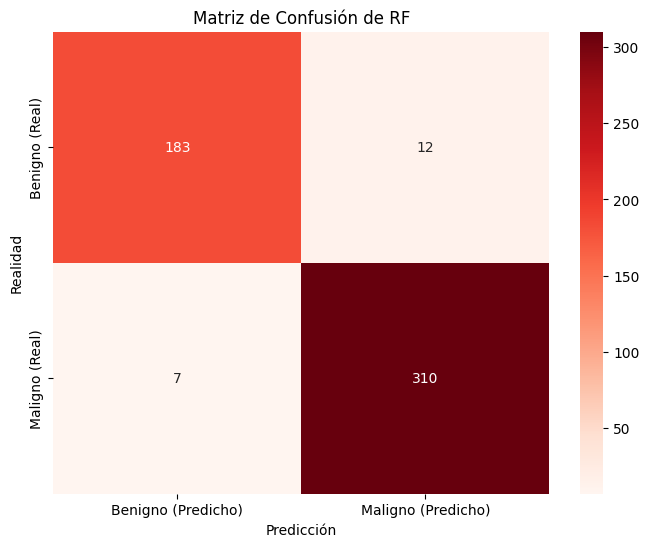

In [ ]:
# Matriz de confusión
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(gs_model, X_train, y_train, cv=5)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train, y_train_pred)

import matplotlib.pyplot as plt
import seaborn as sns
# Crear la visualización con seaborn.heatmap. annot muestra número y fmt tipo decimal
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Benigno (Predicho)', 'Maligno (Predicho)'],
            yticklabels=['Benigno (Real)', 'Maligno (Real)'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión de RF')
plt.show()

#Precission, Recall & F1

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(precision_score(y_train, y_train_pred))
print(recall_score(y_train, y_train_pred))
print(f1_score(y_train, y_train_pred))

0.9627329192546584
0.9779179810725552
0.9702660406885759


#Feature Importance

/tmp/ipykernel_663/2967821903.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


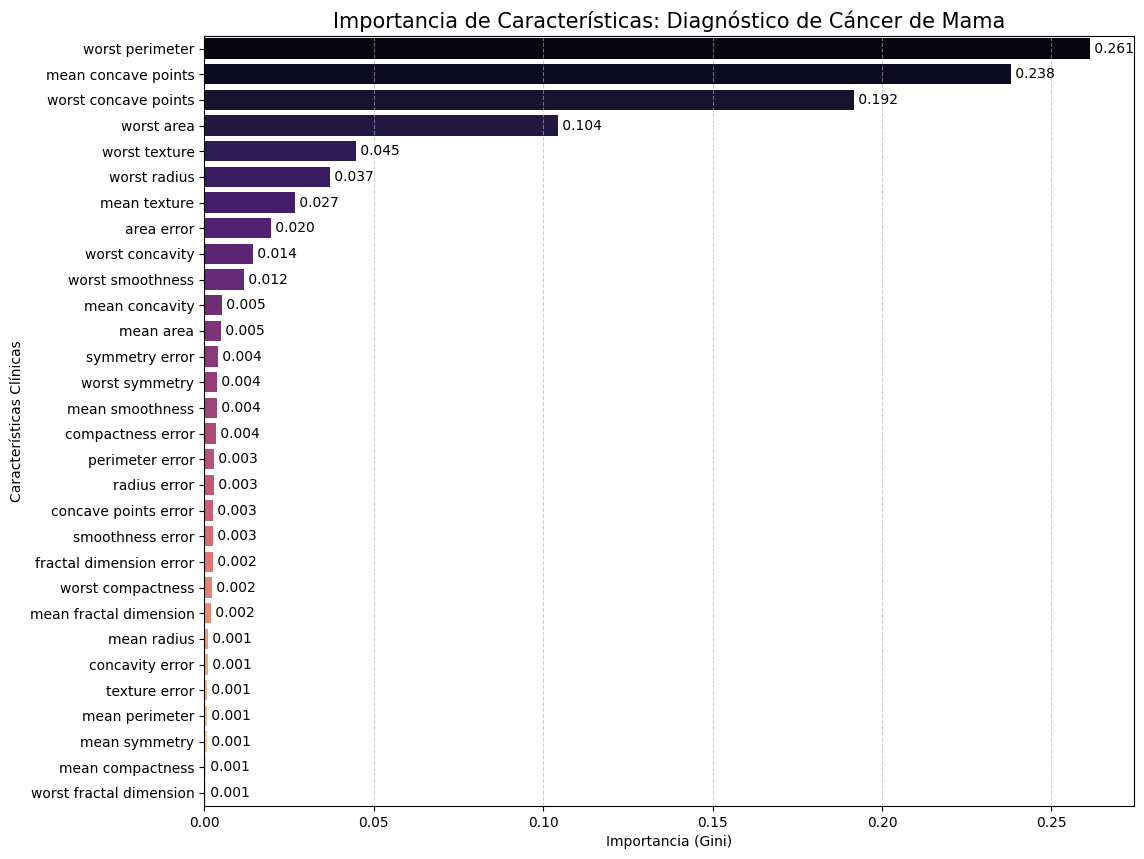

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# 1. Recuperar los nombres de las columnas
# Cargamos el dataset original solo para extraer los nombres de las características
data = load_breast_cancer()
feature_names = data.feature_names

# 2. Extraer las importancias de tu mejor modelo del Grid Search
# Asegúrate de que 'grid_search' sea el nombre de tu objeto de búsqueda
importances = rs_model.feature_importances_

# 3. Crear el DataFrame para la gráfica
feature_importance_df = pd.DataFrame({
    'Característica': feature_names,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

# 4. Graficar
plt.figure(figsize=(12, 10))
sns.barplot(
    x='Importancia',
    y='Característica',
    data=feature_importance_df,
    palette='magma'
)

plt.title('Importancia de Características: Diagnóstico de Cáncer de Mama', fontsize=15)
plt.xlabel('Importancia (Gini)')
plt.ylabel('Características Clínicas')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Añadir etiquetas de valor
for index, value in enumerate(feature_importance_df['Importancia']):
    plt.text(value, index, f' {value:.3f}', va='center')

plt.show()

#Permutation Importance

Mide cuanto sufre el modelo en la métrica deseada si se quita una de las características. Es el detector de mentiras.

En el mundo de Random Forest, a la importancia se le llama habitualmente "Gini Importance" o "Mean Decrease Impurity" (MDI) por tradición, porque Gini es el **valor por defecto.**

Sin embargo, si tu modelo usa criterion='entropy', lo que el código hace internamente es medir **cuánto se redujo la Entropía** (la incertidumbre) gracias a cada variable.

- *Gini mide la pureza.*

- *Entropy mide la información ganada.*

En la práctica, los resultados de importancia suelen ser casi idénticos con ambos criterios, pero técnicamente, al usar entropía, la gráfica anterior está mostrando **la Ganancia de Información de cada variable.**

Como el cálculo de "importancia por impureza" (ya sea Gini o Entropía) tiene un pequeño vicio (tiende a dar más importancia a variables con muchos valores numéricos distintos), la Permutación es el juez imparcial. **A la permutación no le importa si se usa Gini, Entropía o si el modelo es una caja negra: solo le importa cuánto se rompe el F1-Score si "ensuciamos" una columna.**

En el dataset de cáncer de mama, hay mucha correlación. Por ejemplo, el "radio", el "perímetro" y el "área" de la célula dicen casi lo mismo (si uno sube, los otros también). La importancia Gini/Entropía que sacamos antes suele repartir el premio entre las tres.

La Permutación es más cruel: si barajas el "área" pero dejas el "radio" intacto, el modelo **quizás ni se entera porque usa el radio para compensar.**

Esto te permite identificar qué variables son realmente únicas y cuáles son solo "eco" de otras.

**Última comprobación antes de terminar:**

Cuando mires la gráfica de barras de la permutación, fíjate en la línea de error (el palito que sale de la barra).

- Si la barra es larga y el palito de error es corto, tienes un biomarcador consistente.

- Si el palito de error es muy largo (mucha desviación estándar), significa que la importancia de esa variable depende mucho de qué pacientes caigan en el test. No es tan fiable.

**¿Qué hace exactamente n_repeats=10?**

Imagina que barajas una columna (la de "radio del tumor"). Como es un proceso aleatorio, puede que por pura suerte el nuevo orden "ruidoso" siga teniendo cierta coherencia con la respuesta.

Si solo lo haces 1 vez, el resultado de la importancia podría estar sesgado por esa "suerte" al barajar.

Al poner n_repeats=10, el algoritmo baraja la columna 10 veces distintas y calcula la caída del F1-score en cada una. Luego hace la media.

Para qué sirve: Para darte estabilidad. Si la desviación estándar (el palito de error en la gráfica) es pequeña tras 10 repeticiones, puedes jurar que esa variable es importante. Si es muy grande, el modelo es inestable con esa característica.

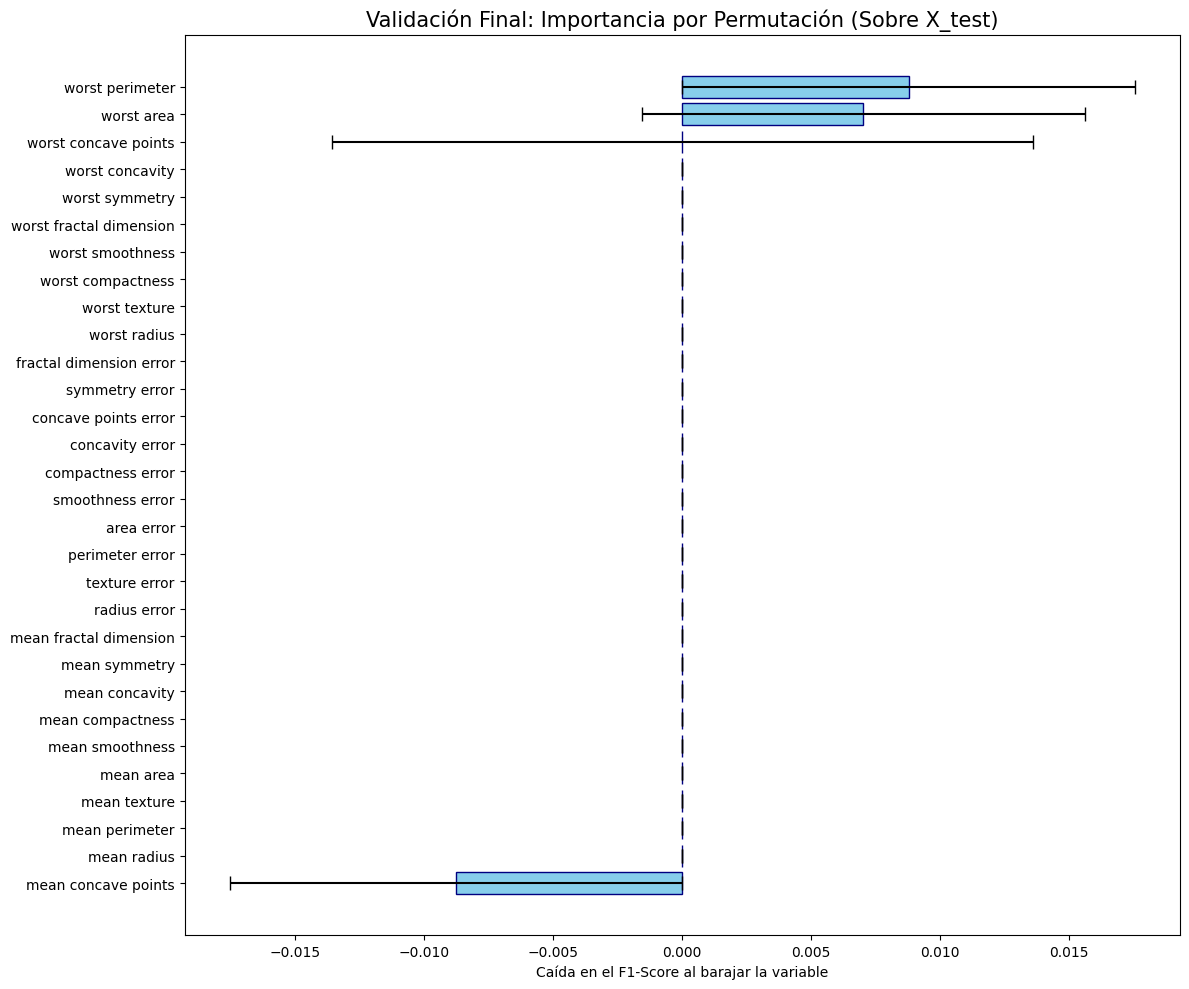

In [9]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Calcular la importancia por permutación
# Usamos el mejor modelo del Grid Search y el conjunto de TEST (X_test, y_test)
result = permutation_importance(
    rs_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# 2. Organizar los resultados
# result.importances_mean contiene el valor medio de la caída de performance
feature_names = data.feature_names
sorted_idx = result.importances_mean.argsort()

perm_df = pd.DataFrame({
    'Variable': [feature_names[i] for i in sorted_idx],
    'Importancia_Media': result.importances_mean[sorted_idx],
    'Desviacion_Std': result.importances_std[sorted_idx]
})

# 3. Graficar (Horizontal para que se lean bien los nombres médicos)
plt.figure(figsize=(12, 10))
plt.barh(perm_df['Variable'], perm_df['Importancia_Media'],
         xerr=perm_df['Desviacion_Std'], color='skyblue', edgecolor='navy', capsize=5)

plt.title("Validación Final: Importancia por Permutación (Sobre X_test)", fontsize=15)
plt.xlabel("Caída en el F1-Score al barajar la variable")
plt.tight_layout()
plt.show()

Esta gráfica (basada en el set de TEST) es la validación real de tu modelo médico.

Significado: Mide cuánto depende el F1-Score del modelo de una variable específica en datos que nunca ha visto. Barajamos la columna y medimos la caída de rendimiento.

Tus resultados médicos: "worst concave points" es el rey absoluto. Si le "quitamos" esa información al modelo, su F1-Score cae drásticamente. Eso te dice que es un biomarcador extremadamente sólido.

Comparación crítica: Si una variable era muy importante en la gráfica de Importancia (Gini/Entropy), pero en la de Permutación casi no aparece, significa que el modelo la usó para "memorizar" el entrenamiento, pero no le sirve para diagnosticar pacientes nuevos (overfitting). ¡Tus gráficas parecen muy consistentes entre sí!

Cuando la importancia por permutación es negativa, significa que al romper esa columna (meterle ruido aleatorio), ¡el modelo ha funcionado mejor que con los datos reales!

Parece una locura, pero tiene una explicación técnica:

Ruido o Contradicción: Esa variable específica está confundiendo al modelo en el set de prueba. Quizás en el entrenamiento parecía útil, pero en los datos nuevos (Test) tiene valores que contradicen la regla general.

Redundancia: Como tienes worst concave points (que es tu variable estrella y está en el top), es muy probable que mean concave points esté aportando información duplicada pero con "ruido". Al modelo le va mejor ignorándola que intentando procesarla.

El fenómeno de las variables "Hermanas" en este dataset es muy común:

worst concave points: Es el valor más extremo (maligno) encontrado en la muestra. Es muy predictivo.

mean concave points: Es el promedio.

A veces, el promedio "suaviza" tanto el dato que acaba engañando al árbol de decisión. Si el modelo intenta usar las dos a la vez, puede entrar en un conflicto lógico. Al barajar la "media", el modelo deja de distraerse y se centra solo en el valor "worst", lo que mejora su puntería.

Si esto fuera un producto médico real que vas a desplegar en un hospital:

Eliminar la variable: Yo probaría a quitar mean concave points (y cualquier otra que salga en negativo) de tu X_train y X_test.

Re-entrenar: Verás que el F1-Score probablemente suba un pelín o se mantenga igual, pero el modelo será más simple y robusto. En medicina, "menos es más": si una variable no ayuda o confunde, fuera.

# Correlation Heat Map

Permite ver correlación entre características. Si dos variables están muy correlacionadas (cerca de 1.0), el Random Forest a menudo se confunde y reparte la importancia entre ambas, lo que explica por qué a veces una sale negativa en la permutación.

Se utilizan solo las 10 más importantes, ya que el resto aparentemente tienen muy poca importancia para la clasificación y así se reduce el ruido visual.

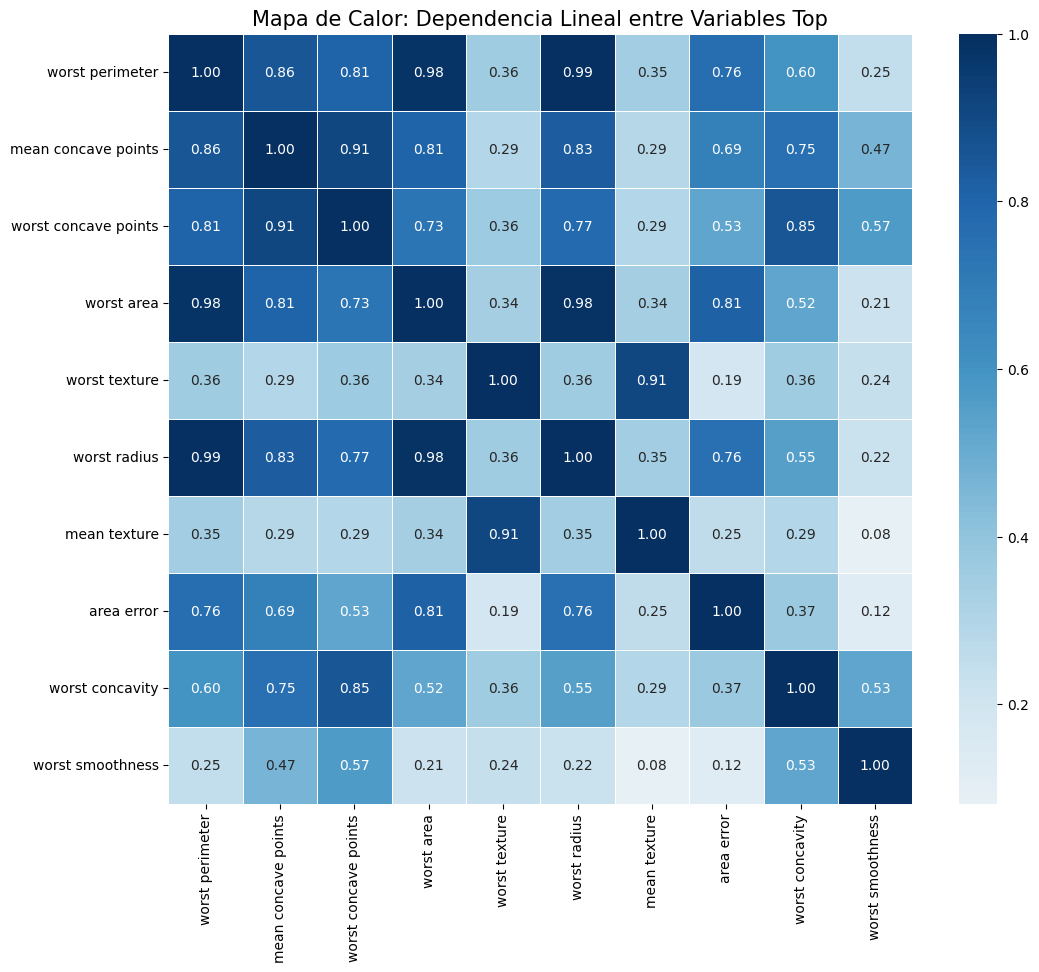

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las top 10 variables del modelo para no saturar el mapa
top_features = feature_importance_df['Característica'].head(10).tolist()
corr_matrix = pd.DataFrame(X_train, columns=data.feature_names)[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor: Dependencia Lineal entre Variables Top", fontsize=15)
plt.show()

# Matriz de Dispersión (PairPlot)

El Pairplot es, en esencia, una "radiografía de separación". Mientras que el heatmap te dice si dos variables se parecen, el pairplot te dice cómo de bien trabajan juntas para diagnosticar.

Para interpretarlo, olvida los números por un momento y céntrate en los colores (asumiendo que Azul = Benigno y Rojo = Maligno). Tienes que mirar dos partes:

1. La Diagonal (Los "cerros" o KDE)
Los gráficos que cruzan una variable consigo misma (ej. worst concave points vs worst concave points) muestran la distribución individual.

Interpretación: Cuanto menos se solapen los "cerros" de colores, mejor es esa variable por sí sola.

Caso médico: Si ves que el cerro rojo está muy a la derecha y el azul muy a la izquierda con poco espacio en medio, esa variable es un "interruptor" casi perfecto para el diagnóstico.

2. Los Cuadros de Dispersión (Nubes de puntos)
Aquí es donde ves la Interacción. Mira un cuadro donde se crucen dos variables distintas (ej. eje X = worst area, eje Y = worst concave points).

Si ves una línea diagonal clara de puntos: Hay correlación (lo que ya sabías por el heatmap).

Si ves que los puntos de colores están "mezclados": Esas dos variables juntas no aportan nada nuevo; el modelo se va a confundir ahí.

Si ves que los colores se separan en "bandas" o grupos limpios: ¡BINGO! Esa combinación de variables es la que permite al Random Forest crear reglas de decisión infalibles.

Ejemplo clínico: Imagina que el area por sí sola tiene algunos puntos rojos mezclados con azules. Pero al mirar el gráfico donde se cruza con concave points, ves que los rojos suben hacia una esquina y los azules se quedan en otra. El modelo "aprende" que si el área es mediana PERO los puntos cóncavos son altos, entonces es maligno.

¿Cómo te ayuda esto a limpiar el modelo?
Si en el pairplot ves que dos variables (ej. worst perimeter y worst area) muestran exactamente la misma nube de puntos y la misma separación de colores:

Confirmas que son redundantes.

Estás viendo visualmente por qué el modelo puede prescindir de una de ellas.

Te da la seguridad de que al quitar una, no estás perdiendo esa "frontera" que separa los colores.

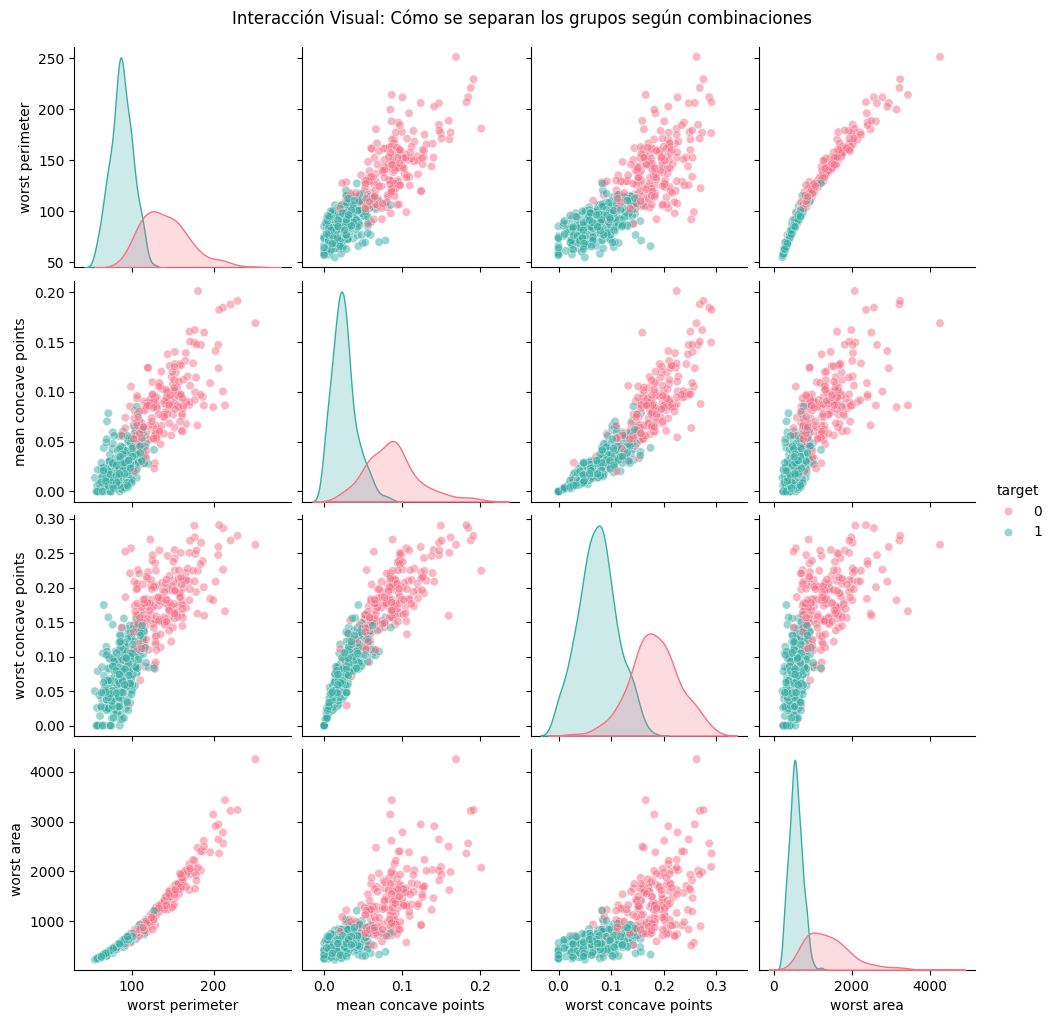

In [13]:
# Creamos un DF temporal con las 4 mejores variables y el diagnóstico real
df_temp = pd.DataFrame(X_train, columns=data.feature_names)
df_temp['target'] = y_train
mejores_4 = feature_importance_df['Característica'].head(4).tolist()

sns.pairplot(df_temp, vars=mejores_4, hue='target', palette='husl', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Interacción Visual: Cómo se separan los grupos según combinaciones", y=1.02)
plt.show()

#Beeswarm Plot (SHAP)

SHAP (SHapley Additive exPlanations) es el nivel más profundo de interpretabilidad que existe ahora mismo.

En medicina es el estándar porque no te dice simplemente "esta variable es importante", sino que te dice: "Este paciente concreto tiene cáncer porque su 'worst concave points' empujó el riesgo un 15% hacia arriba".

Viene de la Teoría de Juegos (Premios Nobel). Imagina que las variables son jugadores de un equipo de fútbol (el modelo). SHAP calcula cuánto "dinero" (probabilidad de diagnóstico) aporta cada jugador al resultado final, teniendo en cuenta todas las combinaciones posibles de sus compañeros.

Tu gráfica SHAP (Beeswarm) es el currículum de tu modelo. ¿Cómo interpretar tu SHAP Beeswarm?

- El Orden de Poder: Las variables arriba (como worst concave points) son las que mandan. Si solo tuvieras 10 segundos para diagnosticar, mirarías esas tres primeras.

- La Lógica del Color: * Fíjate en worst concave points: Los puntos rojos están a la derecha (SHAP > 0). Significa que un valor alto de hendiduras nucleares empuja al modelo a diagnosticar malignidad. Los puntos azules están a la izquierda. Valores bajos empujan hacia "Benigno".

Conclusión: El modelo ha aprendido una relación biológica coherente.

El "Culebreo" (Densidad): Donde la línea se hace más gorda, hay más pacientes acumulados. Si hay mucha dispersión (puntos muy lejos a la derecha), significa que esa variable por sí sola puede ser definitiva para algunos casos extremos.

Si los puntos rojos y azules están muy juntos o mezclados cerca del cero, o tienen un impacto mucho menor que otra feature con la que comparte una correlación alta, esto confirma que es una variable "débil" o redundante que solo añade ruido. El modelo casi no la usa para mover la aguja del diagnóstico.


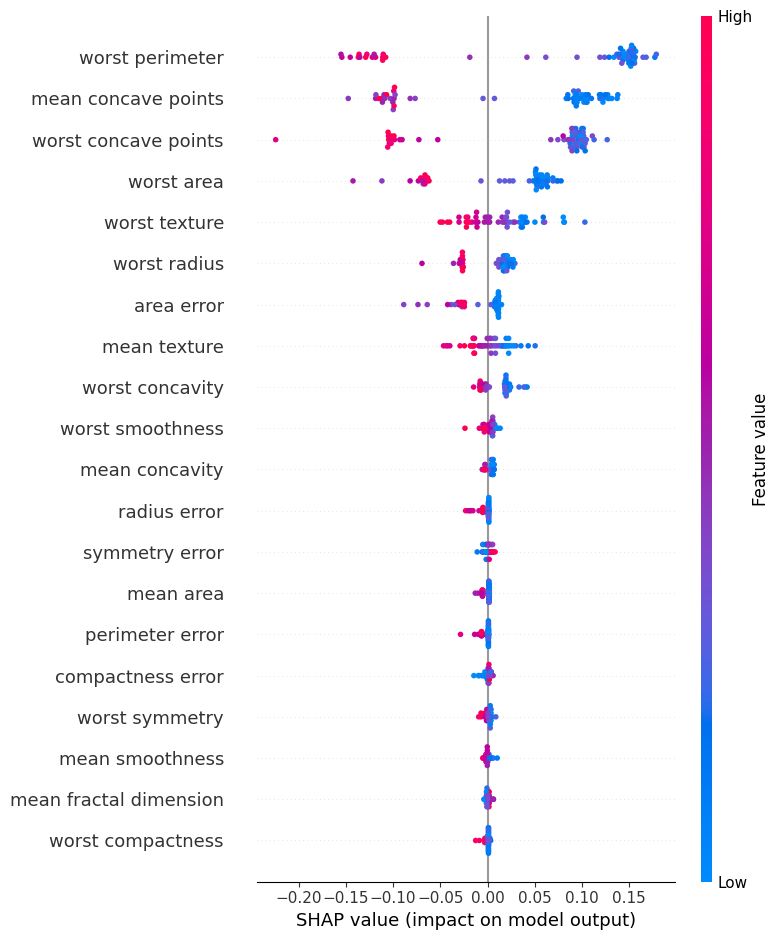

In [15]:
import shap
import numpy as np

# 1. Crear el explicador
explainer = shap.TreeExplainer(rs_model)

# 2. Calcular valores SHAP
# Quitamos el check de aditividad si da problemas de precisión decimal
shap_values = explainer.shap_values(X_test, check_additivity=False)

# 3. EL TRUCO DE LAS DIMENSIONES:
# A veces SHAP devuelve una lista [clase0, clase1] y a veces un array 3D
# Vamos a asegurarnos de extraer la clase 1 (Maligno) correctamente
if isinstance(shap_values, list):
    # Si es una lista, tomamos el elemento 1
    shap_values_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    # Si es un array 3D (muestras, variables, clases), tomamos la clase 1
    shap_values_to_plot = shap_values[:, :, 1]
else:
    # Si ya es 2D, lo dejamos como está
    shap_values_to_plot = shap_values

# 4. Graficar asegurando que X_test coincida
# Si X_test es un DataFrame, SHAP saca los nombres solos.
# Si es un Numpy Array, usamos feature_names=data.feature_names
shap.summary_plot(shap_values_to_plot, X_test, feature_names=data.feature_names)

#Force Plot

#Dependence Plot

# Final Test

In [ ]:
# Resultados finales de modelo potimizado con X_test e y_test

rs_model.score(X_test, y_test)


#Requirements.txt